### Single lane direct transcription using NLP with CasADi

Direct transcription with RK4 quadrature for a double integrator with fixed initial and final states. The double integrator models $n$ vehicles on the same lane that need to respect a fixed safe following distance. We minimize some parameterized cost function
$$
  J_{\alpha,\beta,\gamma} := \sum_{i=1}^n \int_0^{t_f} \alpha x_i(t) + \beta \dot{x}_i(t) + \gamma u_i^2(t) dt ,
$$
where $t_f$ is some final simulation time and $x_i$ and $u_i$ denote the position and control input, respectively, of vehicle $i$ at time $t$.

Suppose we like to impose constraints at times where a vehicle enters and exits the lane, for example, we would like to impose that a vehicle has maximum speed at these times. When the entry and exit times are fixed, this is no problem at all. However, if these times are considered decision variables themselves, it is not clear how to encode such constraints in the current discretized model without introducing additional binary decision variables. A possible solution might be to use a transcribed problem with discretized space instead of time.

We currently support both fixed initial and final conditions, or times of entry and exit with respect to the lane. When using the latter, not that there is some redundancy in this formulation, since we use joint state variables; the vehicle's state at times before its entry time are not relevant and could be left undefined.

*next steps*:
- only define state variables for times between arrival and exit times

In [1]:
import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
# for sharper default plotting
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

In [2]:
from casadi import *
import numpy as np
import math

def lane_trajectories(arrivals=None, exits=None,  # specify arrival and exit times
                      start_lane = 0, end_lane = 5,
                      x0=None, xf=None, # alternatively, specify initial and final state
                      T=20,             # time horizon
                      N=40,             # number of control intervals
                      follow_dist=1,    # safe following distance
                      umin = -1, umax = 1,
                      vmin =  0, vmax = 1,
                      alpha=-1, beta=1, gamma = 10
                     ):
    if x0 is not None:
        n_vehs = len(x0)/2 # number of vehicles on the route
    elif arrivals is not None:
        n_vehs = len(arrivals)
    else:
        raise Exception("Specify arrival/exit times or initial/final states.")
    
    # arrival and exit lane checkpoints:
    # convert [a,e] to timesteps [ai,ei] making sure
    # that [ai*dt,ei*dt] \subseteq [a,e],
    # where dt=T/N is discrete time step size
    arrival_ts = [math.ceil(a / (T/N)) for a in arrivals]
    exit_ts    = [math.floor(e / (T/N)) for e in exits]
    
    # state and control variables
    x = MX.sym('x', 2 * n_vehs)
    u = MX.sym('u', n_vehs)
    
    # build A and B matrices
    A = np.zeros((2*n_vehs, 2*n_vehs))
    B = np.zeros((2*n_vehs, n_vehs))
    for i in range(n_vehs):
        A[2*i, 2*i+1] = 1   # dp/dt = v
        B[2*i+1, i] = 1     # dv/dt = u
    # convert to CasADi
    A = DM(A)
    B = DM(B)
    
    # double integrator dynamics
    xdot = A @ x + B @ u
    
    # some quadratic running cost
    L = 0
    for i in range(n_vehs):
        L += alpha * x[i*2] + beta * x[i*2+1] + gamma* u[i]**2
    
    f = Function('f', [x, u], [xdot, L])
    
    # fixed step Runge-Kutta 4 integrator
    M = 4 # RK4 steps per interval
    DT = T/N/M
    X0 = MX.sym('X0', 2 * n_vehs)
    U = MX.sym('U', n_vehs)
    X = X0
    Q = 0
    for j in range(M):
       k1, k1_q = f(X, U)
       k2, k2_q = f(X + DT/2 * k1, U)
       k3, k3_q = f(X + DT/2 * k2, U)
       k4, k4_q = f(X + DT * k3, U)
       X = X + DT/6*(k1 +2*k2 +2*k3 +k4)
       Q = Q + DT/6*(k1_q + 2*k2_q + 2*k3_q + k4_q)
    F = Function('F', [X0, U], [X, Q],['x0','p'],['xf','qf'])
    
    # parameters for NLP
    J = 0
    w, w0, lbw, ubw = [],[],[],[] # state variable, initial guess, lower/upper bound
    g, lbg, ubg = [],[],[]        # constraint functions, lower/upper bounds
    
    Xk = MX.sym('X0', 2 * n_vehs)
    w += [Xk]
    # initial state constraints
    if x0 is not None:
        lbw += x0; ubw += x0; w0 += x0
    else:
        lbw += [-inf, vmin] * n_vehs
        ubw += [ inf, vmax] * n_vehs
        w0  += [0, vmin] * n_vehs
    
    # enter constraint for initial state
    if 0 in arrival_ts:
        # get vehicle index
        i = arrival_ts.index(0)
        g += [Xk[i*2], Xk[i*2+1]]
        lbg += [start_lane, vmax]; ubg += [start_lane, vmax]
    
    # formulate the NLP
    for k in range(N):
        # new NLP variable for the control
        Uk = MX.sym('U_' + str(k), n_vehs)
        w   += [Uk]
        lbw += [umin] * n_vehs
        ubw += [umax] * n_vehs
        w0  += [0] * n_vehs
    
        # integrate till the end of the interval
        Fk = F(x0=Xk, p=Uk)
        Xk_end = Fk['xf']
        J = J + Fk['qf']
    
        # new NLP variable for state at end of interval
        Xk = MX.sym('X_' + str(k+1), 2 * n_vehs)
        w   += [Xk]
        if k == N-1 and xf is not None:
            # final state constraints
            lbw += xf; ubw += xf
        else:
            # state constraints
            lbw += [ -inf,  vmin] * n_vehs
            ubw += [  inf,  vmax] * n_vehs
        w0  += [0, vmin] * n_vehs
    
        # safe following constraints
        for i in range(n_vehs - 1):
            g += [Xk[i*2] - Xk[(i+1)*2]]
            lbg += [follow_dist]
            ubg += [inf]
    
        # # enter and exit constraints
        if k+1 in arrival_ts:
            # get vehicle index
            i = arrival_ts.index(k+1)
            g += [Xk[i*2], Xk[i*2+1]]
            lbg += [start_lane, vmax]; ubg += [start_lane, vmax]
        if k+1 in exit_ts:
            # get vehicle index
            i = exit_ts.index(k+1)
            g += [Xk[i*2], Xk[i*2+1]]
            lbg += [end_lane, vmax]; ubg += [end_lane, vmax]
    
        # add equality constraint at knot points
        g   += [Xk_end - Xk]
        lbg += [0, 0] * n_vehs
        ubg += [0, 0] * n_vehs
    
    # solver options to suppress output
    opts = {
        "print_time": False,     # suppress CasADi's own output
        "ipopt.print_level": 0,  # suppress IPOPT output
        "ipopt.sb": "yes"        # suppress IPOPT banner
    }
    
    # create an NLP solver
    prob = {'f': J, 'x': vertcat(*w), 'g': vertcat(*g)}
    solver = nlpsol('solver', 'ipopt', prob, opts)
    
    # solve the NLP
    sol = solver(x0=w0, lbx=lbw, ubx=ubw, lbg=lbg, ubg=ubg)
    w_opt = sol['x'].full().flatten()
    
    # check solver status
    stats = solver.stats()
    
    print(stats['return_status'])
    if not stats['success']:
        g_val = Function("g_fun", [prob['x']], [prob['g']])(sol['x'])
        print("Constraint residuals:", g_val.full().flatten())

    # time grid for plotting
    tgrid = [T/N*k for k in range(N+1)]
    
    # reshape into nice vectors
    # pad control with dummy np.nan to make regular array
    w = np.append(w_opt, [np.nan] * n_vehs).reshape(N + 1, n_vehs * 3)
    state = w[:, 0:2*n_vehs]
    x = state[:, 0::2] # positions
    v = state[:, 1::2] # speeds
    u = w[:, 2*n_vehs:] # controls (N.B. padded!)
    
    return tgrid, x, v, u

In [3]:
def plot_trajectories(tgrid, x, v, u, vmin=0, vmax=1, umin=-1, umax=1, start_lane=None, end_lane=None, axs=None,
         style={ 'linestyle': '-' }, *args, **kwargs):
    if axs is None:
        fig, (ax1, ax2, ax3) = plt.subplots(nrows=3, sharex=True, figsize=(8,8),
                                            gridspec_kw={'height_ratios': [3, 1, 1]})
    else:
        ax1, ax2, ax3 = axs
    
    # mask the part outside the lane
    eps = 1e-3
    if start_lane is not None and end_lane is not None:
        mask = (x < start_lane - eps) | (x > end_lane + eps)
        x = np.ma.masked_where(mask, x)
        v = np.ma.masked_where(mask, v)
        u = np.ma.masked_where(mask, u)

    n_vehs = x.shape[1]

    # plot positions
    ax1.plot(tgrid, x, **style)
    ax1.legend([f'x{i}' for i in range(n_vehs)], loc='upper left', bbox_to_anchor=(1, 1))
    ax1.set_title('position')

    # plot velocities
    ax2.plot(tgrid, v, **style)
    ax2.legend([f'v{i}' for i in range(n_vehs)], loc='upper left', bbox_to_anchor=(1, 1))
    ax2.set_ylim([vmin - 0.1*(vmax-vmin), vmax + 0.1*(vmax-vmin)])
    ax2.set_title('velocity')

    # plot accelerations (controls)
    ax3.step(tgrid, u, **style, where='post')
    ax3.legend([f'u{i}' for i in range(n_vehs)], loc='upper left', bbox_to_anchor=(1, 1))
    # ax3.set_ylim([umin - 0.1*(umax-umin), umax + 0.1*(umax-umin)])
    ax3.set_title('acceleration (control)')
    
    ax1.grid(True)
    ax2.grid(True)
    ax3.grid(True)
    plt.xlabel('t')
    if axs is None:
        plt.show()

In [4]:
def demo():
    system_params = { 'vmin': 0, 'vmax': 2, 'umin': -5, 'umax': 1, 'T': 20, 'N': 200, }
    arrivals = [0, 1, 2, 6]
    exits    = [5, 9, 10, 12]
    sol1 = lane_trajectories(arrivals, exits, gamma=0, **system_params)
    sol2 = lane_trajectories(arrivals, exits, gamma=1, **system_params)
    sol3 = lane_trajectories(arrivals, exits, gamma=20, **system_params)
    
    fig, axs = plt.subplots(nrows=3, figsize=(8,8), gridspec_kw={'height_ratios': [3, 1, 1]})
    plot_trajectories(*sol1, **system_params, axs=axs);
    plot_trajectories(*sol2, **system_params, axs=axs, style={'linestyle': '--'});
    plot_trajectories(*sol3, **system_params, axs=axs, style={'linestyle': '-.'});
    plt.subplots_adjust(hspace=0.5) 

Solve_Succeeded
Solve_Succeeded
Solve_Succeeded


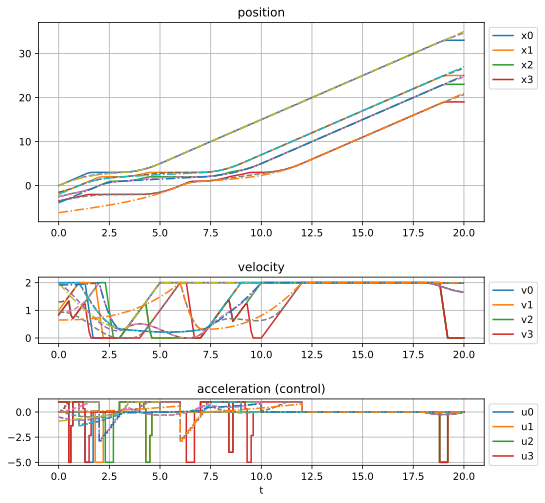

In [7]:
demo()